In [ ]:
#==========================================================
# MODULE 1 : MOUNT GOOGLE DRIVE
#==========================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#==========================================================
# MODULE 2 : IMPORT LIBRARIES
#==========================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [ ]:
#==========================================================
# MODULE 3 : LOCATE DATASET
#==========================================================

dataset_path = "/content/drive/MyDrive/dataset"

print("Dataset Exists :", os.path.exists(dataset_path))

files = [
    f for f in os.listdir(dataset_path)
    if f.endswith(".csv")
]

print("CSV Files :", len(files))

print("\nFirst 10 Files\n")

for f in files[:10]:
    print(f)

Dataset Exists : True
CSV Files : 169

First 10 Files

part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv


In [ ]:
#==========================================================
# MODULE 4 : LOAD CSV FILES
#==========================================================

random.seed(42)

sample_files = random.sample(
    files,
    min(10, len(files))
)

print("Files Selected\n")

for f in sample_files:
    print(f)

dfs = []

for file in sample_files:

    path = os.path.join(dataset_path, file)

    temp = pd.read_csv(path)

    dfs.append(temp)

df = pd.concat(
    dfs,
    ignore_index=True
)

print("\nDataset Shape")

print(df.shape)

Files Selected

part-00163-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00027-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00070-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00062-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00058-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00035-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00026-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00139-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00022-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

Dataset Shape
(2579444, 47)


In [ ]:
#==========================================================
# MODULE 5 : BINARY IDS DATASET
#==========================================================

print("Original Classes\n")

print(df["label"].value_counts())

df["binary_label"] = df["label"].apply(
    lambda x: 0 if x=="BenignTraffic" else 1
)

print("\nBinary Distribution\n")

print(df["binary_label"].value_counts())

print("\nClass Ratio\n")

print(df["binary_label"].value_counts(normalize=True))

print("\nDataset Shape")

print(df.shape)

Original Classes

label
DDoS-ICMP_Flood            398503
DDoS-UDP_Flood             298298
DDoS-TCP_Flood             248300
DDoS-PSHACK_Flood          225669
DDoS-SYN_Flood             224269
DDoS-RSTFINFlood           223690
DDoS-SynonymousIP_Flood    198519
DoS-UDP_Flood              183383
DoS-TCP_Flood              147688
DoS-SYN_Flood              112363
BenignTraffic               61119
Mirai-greeth_flood          55290
Mirai-udpplain              49299
Mirai-greip_flood           41387
DDoS-ICMP_Fragmentation     24820
MITM-ArpSpoofing            17001
DDoS-UDP_Fragmentation      15799
DDoS-ACK_Fragmentation      15789
DNS_Spoofing                 9946
Recon-HostDiscovery          7392
Recon-OSScan                 5390
Recon-PortScan               4555
DoS-HTTP_Flood               3899
VulnerabilityScan            2027
DDoS-HTTP_Flood              1580
DDoS-SlowLoris               1303
DictionaryBruteForce          689
BrowserHijacking              324
CommandInjection        

In [ ]:
print(df.head())

print(df.info())

print(df.isnull().sum().sum())

   flow_duration  Header_Length  Protocol Type  Duration       Rate  \
0       3.586897        1991.80           6.77     79.65  52.548220   
1       0.000000           0.00           0.99     63.36  98.346524   
2       0.000000         182.00          17.00     64.00  19.143594   
3       0.060127           2.96           1.05     64.00  16.939950   
4       0.000000           0.00           1.00     64.00  50.140512   

       Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...  \
0  52.548220    0.0              0.0              0.0              0.0  ...   
1  98.346524    0.0              0.0              0.0              0.0  ...   
2  19.143594    0.0              0.0              0.0              0.0  ...   
3  16.939950    0.0              0.0              0.0              0.0  ...   
4  50.140512    0.0              0.0              0.0              0.0  ...   

   Tot size           IAT  Number   Magnitue      Radius    Covariance  \
0    197.49  8.295626e+0

In [ ]:
#==========================================================
# MODULE 6 : FEATURE AND LABEL SEPARATION
#==========================================================

X = df.drop(["label", "binary_label"], axis=1)
y = df["binary_label"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nClass Distribution")
print(y.value_counts())

print("\nClass Ratio")
print(y.value_counts(normalize=True))

X Shape: (2579444, 46)
y Shape: (2579444,)

Class Distribution
binary_label
1    2518325
0      61119
Name: count, dtype: int64

Class Ratio
binary_label
1    0.976305
0    0.023695
Name: proportion, dtype: float64


In [ ]:
#==========================================================
# MODULE 7 : TRAIN TEST SPLIT
#==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1934583, 46)
(644861, 46)
(1934583,)
(644861,)


In [ ]:
#==========================================================
# MODULE 8 : FEATURE SCALING
#==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [ ]:
#==========================================================
# MODULE 9 : SAVE SCALER
#==========================================================

import pickle

with open("/content/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler Saved")

Scaler Saved


In [ ]:
#==========================================================
# MODULE 10 : SAVE DATASET
#==========================================================

import pickle
import os

data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

save_path = "/content/binary_dataset.pkl"

with open(save_path, "wb") as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved Successfully")
print("Size:", round(os.path.getsize(save_path)/(1024*1024), 2), "MB")

Saved Successfully
Size: 964.3 MB


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(os.path.getsize("/content/binary_dataset.pkl")/(1024*1024))

(1934583, 46)
(644861, 46)
964.3011798858643


In [ ]:
#==========================================================
# MODULE 11 : LOAD BINARY DATASET
#==========================================================

import pickle

with open("/content/binary_dataset.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1934583, 46)
(644861, 46)
(1934583,)
(644861,)


In [ ]:
#==========================================================
# MODULE 12 : CREATE CLIENTS
#==========================================================

import numpy as np

NUM_CLIENTS = 500

indices = np.random.permutation(len(X_train))

client_size = len(indices) // NUM_CLIENTS

client_data = []

for i in range(NUM_CLIENTS):

    start = i * client_size
    end = (i + 1) * client_size

    idx = indices[start:end]

    client_x = X_train[idx]
    client_y = y_train.iloc[idx]

    client_data.append((client_x, client_y))

print("Clients:", len(client_data))
print("Samples per client:", client_data[0][0].shape)

Clients: 500
Samples per client: (3869, 46)


In [ ]:
#==========================================================
# MODULE 13 : SAVE CLIENT DATA
#==========================================================

import pickle

with open("/content/client_data.pkl", "wb") as f:
    pickle.dump(client_data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Client data saved.")

Client data saved.


In [ ]:
#==========================================================
# MODULE 14 : CREATE GLOBAL MODEL
#==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_binary_model():

    model = Sequential([
        Input(shape=(46,)),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


global_model = create_binary_model()

global_weights = global_model.get_weights()

print("Global Model Ready")

Global Model Ready


In [ ]:
#==========================================================
# MODULE 15 : CLIENT TRAINING
#==========================================================

def train_client(client_x, client_y, global_weights):

    local_model = create_binary_model()

    local_model.set_weights(global_weights)

    local_model.fit(
        client_x,
        client_y,
        epochs=1,
        batch_size=64,
        verbose=0
    )

    return local_model.get_weights()

print("Client Trainer Ready")

Client Trainer Ready


In [ ]:
#==========================================================
# MODULE 16 : FEDERATED AVERAGING
#==========================================================

import numpy as np

def federated_average(local_weights):

    avg_weights = []

    for weights in zip(*local_weights):
        avg_weights.append(np.mean(weights, axis=0))

    return avg_weights

print("FedAvg Function Ready")

FedAvg Function Ready


In [ ]:
print(df.columns.tolist())

['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label', 'binary_label']


In [ ]:
#==========================================================
# MODULE 17 : FEDERATED LEARNING
#==========================================================

import random
from sklearn.metrics import accuracy_score

ROUNDS = 10
CLIENTS_PER_ROUND = 50

accuracy_history = []

for rnd in range(ROUNDS):

    print(f"\nRound {rnd+1}")

    # Randomly select 50 clients
    selected_clients = random.sample(client_data, CLIENTS_PER_ROUND)

    local_weights = []

    # Train each selected client
    for client_x, client_y in selected_clients:

        weights = train_client(
            client_x,
            client_y,
            global_weights
        )

        local_weights.append(weights)

    # Aggregate local models
    global_weights = federated_average(local_weights)

    global_model.set_weights(global_weights)

    # Evaluate after aggregation
    predictions = (
        global_model.predict(X_test, verbose=0) > 0.5
    ).astype(int)

    acc = accuracy_score(y_test, predictions)

    accuracy_history.append(acc)

    print("Accuracy =", round(acc, 4))


Round 1
Accuracy = 0.9864

Round 2
Accuracy = 0.9866

Round 3
Accuracy = 0.9868

Round 4
Accuracy = 0.9878

Round 5
Accuracy = 0.9879

Round 6
Accuracy = 0.989

Round 7
Accuracy = 0.9886

Round 8
Accuracy = 0.9896

Round 9
Accuracy = 0.9894

Round 10
Accuracy = 0.9897


In [ ]:
variables = [
    "client_data",
    "poisoned_client_data",
    "global_model",
    "global_weights",
    "X_train",
    "X_test",
    "y_train",
    "y_test"
]

for v in variables:
    print(v, ":", v in globals())

client_data : True
poisoned_client_data : False
global_model : True
global_weights : True
X_train : True
X_test : True
y_train : True
y_test : True


In [ ]:
import random

random.seed(42)

MALICIOUS_RATIO = 0.10   # 10% malicious clients

malicious_ids = random.sample(
    range(NUM_CLIENTS),
    int(NUM_CLIENTS * MALICIOUS_RATIO)
)

print("Number of malicious clients:", len(malicious_ids))
print("First 10 malicious IDs:", malicious_ids[:10])

Number of malicious clients: 50
First 10 malicious IDs: [327, 57, 12, 379, 140, 125, 114, 71, 377, 52]


In [ ]:
poisoned_client_data = []

for cid, (X_client, y_client) in enumerate(client_data):

    if cid in malicious_ids:
        y_poison = 1 - y_client      # Label flipping attack
        poisoned_client_data.append((X_client, y_poison))
    else:
        poisoned_client_data.append((X_client, y_client))

print("Poisoned client datasets:", len(poisoned_client_data))

Poisoned client datasets: 500


In [ ]:
print("client_data:", 'client_data' in globals())
print("malicious_ids:", 'malicious_ids' in globals())
print("poisoned_client_data:", 'poisoned_client_data' in globals())

client_data: True
malicious_ids: True
poisoned_client_data: True


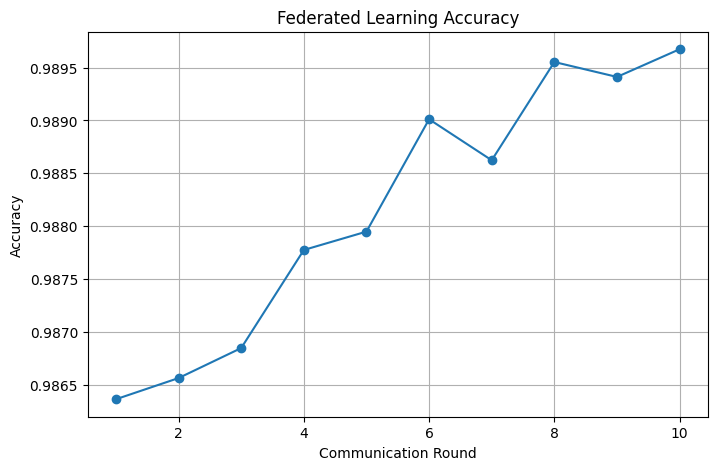

In [ ]:
#==========================================================
# MODULE 18 : ACCURACY PLOT
#==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, ROUNDS+1),
    accuracy_history,
    marker='o'
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("Federated Learning Accuracy")

plt.grid(True)

plt.show()

In [ ]:
#==========================================================
# MODULE 19 : FINAL EVALUATION
#==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

pred = (
    global_model.predict(X_test, verbose=0) > 0.5
).astype(int)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, pred))

Accuracy : 0.9896737436439791
Precision: 0.9990946267298237
Recall   : 0.9903205465222108
F1 Score : 0.9946882381047722

Confusion Matrix

[[ 14715    565]
 [  6094 623487]]


In [42]:
print("df" in globals())

True


In [ ]:
import os
import pandas as pd

dataset_path = "/content/drive/MyDrive/dataset"

files = sorted(os.listdir(dataset_path))

dfs = []

for file in files[:5]:      # only first 5 files
    print(file)
    dfs.append(pd.read_csv(os.path.join(dataset_path,file)))

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
(1191264, 47)


In [ ]:
#==========================================================
# MODULE 20 : SAVE FL MODEL
#==========================================================

global_model.save("/content/fl_model.keras")

print("Federated Model Saved Successfully")

Federated Model Saved Successfully


In [43]:
print(X_train.shape)
print(X_test.shape)
print(len(client_data))
print(len(poisoned_client_data))

(1934583, 46)
(644861, 46)
500
500


In [45]:
import pickle

with open("/content/drive/MyDrive/binary_dataset.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "client_data": client_data,
        "poisoned_client_data": poisoned_client_data,
        "NUM_CLIENTS": NUM_CLIENTS
    }, f)

print("Saved successfully.")

Saved successfully.
